In [11]:
!pip install yfinance

In [3]:
#importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf

In [4]:
gold = yf.download("GC=F", start="2015-01-01", end="2024-01-01")
oil  = yf.download("CL=F", start="2015-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
gold_close = gold["Close"].squeeze()
oil_close  = oil["Close"].squeeze()

# Merge into one dataframe
df = pd.DataFrame({
    "Gold_Price": gold_close,
    "Oil_Price":  oil_close
})

# Drop missing values
df = df.dropna()

# Check it
print(df.head())
print(df.shape)

             Gold_Price  Oil_Price
Date                              
2015-01-02  1186.000000  52.689999
2015-01-05  1203.900024  50.040001
2015-01-06  1219.300049  47.930000
2015-01-07  1210.599976  48.650002
2015-01-08  1208.400024  48.790001
(2261, 2)


In [6]:
X=df[["Oil_Price"]]
y=df["Gold_Price"]
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [8]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [9]:
pred = model.predict(X_test)

mse  = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

In [10]:
print(f"--- Model Evaluation ---")
print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2}")

--- Model Evaluation ---
MAE  : 217.38922895351328
RMSE : 253.19188503932187
R²   : 0.2807563415157919


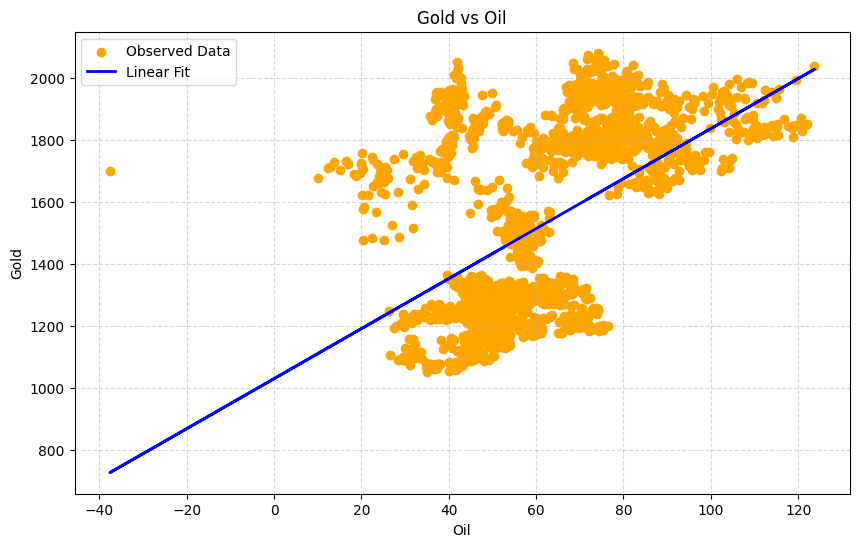

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='orange', label='Observed Data')
plt.plot(X, model.predict(X), color='blue', linewidth=2, label='Linear Fit')
plt.title('Gold vs Oil')
plt.xlabel('Oil')
plt.ylabel('Gold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/home/dara/Desktop/ML_Projects/gold_vs_oil.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
pwd


'/home/dara'